In [1]:
import numpy as np
from simulation import Simulation

In [2]:
sim = Simulation(n_macro_particles='co', threads=10)

Converting sequence "synchrotron":   0%|          | 0/1990 [00:00<?, ?it/s]

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


In [3]:
for i in np.linspace(0,sim.line.get_length(), 13, endpoint=False):
    sim.insert_dipole_error(strength=1e-3, s=i)

Slicing line:   0%|          | 0/3981 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/3991 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/3993 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4003 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4005 [00:00<?, ?it/s]

...

Slicing line:   0%|          | 0/4019 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4021 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4031 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4041 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4043 [00:00<?, ?it/s]

In [4]:
sim.add_space_charge(beam_intensity=5e11, n_interactions=100)

Creating spacecharge elements:   0%|          | 0/100 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/3981 [00:00<?, ?it/s]

In [5]:
sim.run(30)

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Turn: 0
Turn: 1
Turn: 2
Turn: 3
Turn: 4
Turn: 5
Turn: 6
Turn: 7
Turn: 8
Turn: 9
Turn: 10
Turn: 11
Turn: 12
Turn: 13
Turn: 14
Turn: 15
Turn: 16
Turn: 17
Turn: 18
Turn: 19
Turn: 20
Turn: 21
Turn: 22
Turn: 23
Turn: 24
Turn: 25
Turn: 26
Turn: 27
Turn: 28
Turn: 29


In [6]:
sim.save('co_1e-3')


File saved at data/co_1e-3


/home/rsimpson/MPhys Project/Code/Accelerator Simulation/unified/simulation.py:170: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['W_matrix'], dtype='str')]

  df_twiss.to_hdf(f'data/{filename}.h5',


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


(0.0, 10.0)

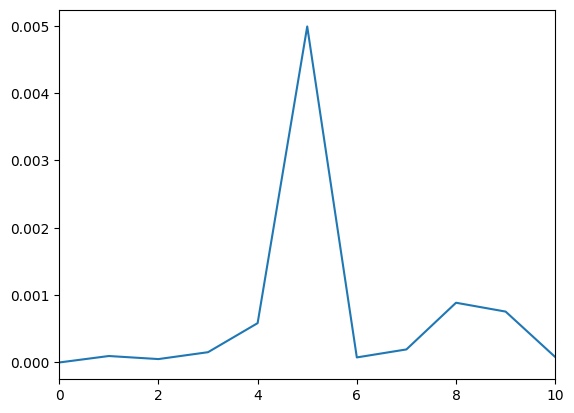

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import lombscargle
s=sim.line.twiss(method='4d', freeze_longitudinal=True).s
y=sim.line.twiss(method='4d', freeze_longitudinal=True).y


freqs = np.linspace(0.00, 50, 10000)
angular_freqs = 2 * np.pi * freqs

pgram = lombscargle(s, y - np.mean(y), angular_freqs)
plt.plot(pgram)
plt.xlim(0,10)

In [14]:
sim.line.twiss(method='4d', freeze_longitudinal=True)

TwissTable: 4572 rows, 70 cols
name                               s             x            px             y            py ...
spacecharge_0                      0  -1.09145e-06   1.33047e-07   -0.00505298   -0.00145015
dipole_error                       0  -1.09145e-06   1.33047e-07   -0.00505298   -0.00145015
synchrotron$start_aper             0  -1.09145e-06   1.33047e-07   -0.00505298  -0.000450153
synchrotron$start                  0  -1.09145e-06   1.33047e-07   -0.00505298  -0.000450153
sp0_datum_aper                     0  -1.09145e-06   1.33047e-07   -0.00505298  -0.000450153
sp0_datum                          0  -1.09145e-06   1.33047e-07   -0.00505298  -0.000450153
sp0_dipfr8_0_aper                  0  -1.09145e-06   1.33047e-07   -0.00505298  -0.000450153
sp0_dipfr8_0                       0  -1.09145e-06   1.33047e-07   -0.00505298  -0.000450153
sp0_dipfr8_1_aper               0.06  -1.08343e-06   1.33995e-07   -0.00508009  -0.000453503
sp0_dipfr8_1                    0.0

In [13]:
len(sim.line.elements)

4571

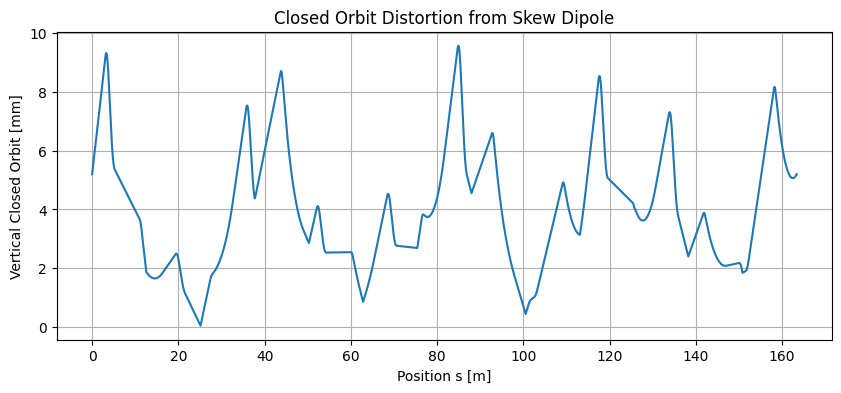

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(s, y * 1000) # Convert to mm
plt.xlabel('Position s [m]')
plt.ylabel('Vertical Closed Orbit [mm]')
plt.title('Closed Orbit Distortion from Skew Dipole')
plt.grid(True)
plt.show()

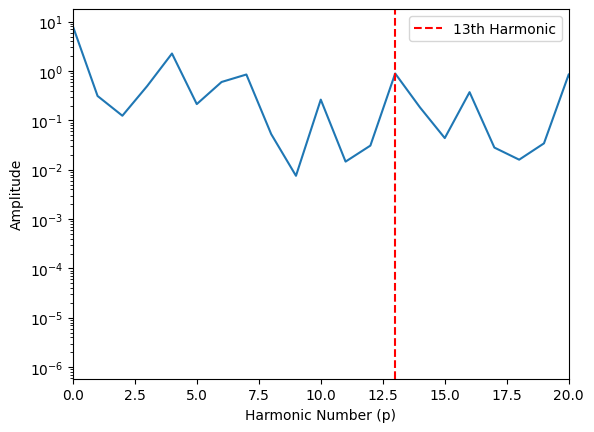

In [6]:
num_points = 2048
s_regular = np.linspace(0, s[-1], num_points)
y_regular = np.interp(s_regular, s, y)

y_fft = np.fft.rfft(y_regular)
harmonics = np.fft.rfftfreq(num_points, d=(s[-1]/num_points) / s[-1])

# 4. Plot
plt.semilogy(harmonics, np.abs(y_fft)) # Use log scale to see tiny harmonics
plt.xlim(0, 20)
plt.axvline(13, color='r', linestyle='--', label='13th Harmonic')
plt.xlabel('Harmonic Number (p)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()